# Data Preprocessing
This file contains logic for:
- downloading the raw data and construct a dataset
- necessary transformation for ResNet input
- sampling Gaussian Noise via dataloader
- sampling t and r via lognorm method
- sampling t from Unif(0,1)
- doing image corruption to prepare for class data

some key features of sampling:
- mask_rate of Class : randomly set to a black image
- equal_rate of t,r : t = r
- sample distribution: str


some trials (delete them) are also contained

In [2]:
# create the directory for data

from pathlib import Path
import requests
import zipfile
import shutil


# Step 1: Define paths and URL
data_dir = Path("data")
zip_path = data_dir / "tiny-imagenet-200.zip"
extract_dir = data_dir / "tiny-imagenet-200"
url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"

# Step 2: Create data/ directory if it doesn't exist
data_dir.mkdir(parents=True, exist_ok=True)

# Step 3: Download the zip file if not already downloaded
if not zip_path.exists():
    print(f"Downloading Tiny ImageNet to {zip_path}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(zip_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete.")
else:
    print("Zip file already exists, skipping download.")

# Step 4: Extract the zip file if not already extracted
if not extract_dir.exists():
    print(f"Extracting to {extract_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")
else:
    print("Data already extracted.")


val_dir = Path("data/tiny-imagenet-200/val")
val_images_dir = val_dir / "images"
val_annotations_path = val_dir / "val_annotations.txt"
val_sorted_dir = val_dir.parent / "val_sorted"

# Create output dir
val_sorted_dir.mkdir(exist_ok=True)

# Read annotations
with open(val_annotations_path, "r") as f:
    for line in f:
        parts = line.strip().split("\t") 
        # split the line:<image_filename> <class_id> <bbox_x0> <bbox_y0> <bbox_x1> <bbox_y1>
        # into parts that we can harness
        filename, class_name = parts[0], parts[1]

        # Create class directory
        class_dir = val_sorted_dir / class_name
        class_dir.mkdir(exist_ok=True)

        # Move image to class folder
        src = val_images_dir / filename
        dst = class_dir / filename
        shutil.copy(src, dst)

print("Validation set reorganized successfully.")


Zip file already exists, skipping download.
Data already extracted.
Validation set reorganized successfully.


In [13]:
# create dataloaders
# It's no use to return a 


from torchvision import datasets, transforms
import torch, torchvision
from torch.utils.data import DataLoader
import config


weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()

train_dir = extract_dir / 'train'
train_dataset = datasets.ImageFolder(root = train_dir,
                                      transform = transforms.ToTensor(),
                                      target_transform= None)
val_dir = extract_dir / 'val_sorted'
val_dataset = datasets.ImageFolder(root = val_dir,
                                      transform = auto_transforms,
                                      target_transform= None)

train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size = config.batch_size,
                              shuffle=True,
                              num_workers = config.num_workers)
print(auto_transforms)


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


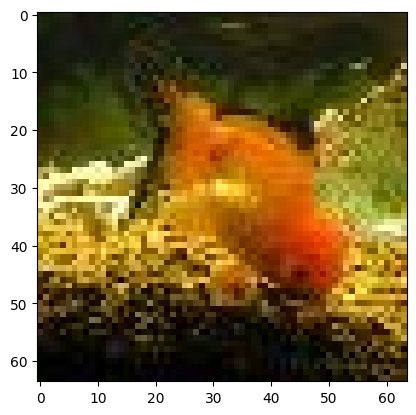

In [ ]:
import matplotlib.pyplot as plt

a,b = train_dataset[1]
plt.imshow(a.permute(1,2,0)) # a fish

In [ ]:
# import torch
# import torchvision.transforms as T
# import torchvision.transforms.functional as TF
# import random
# import cv2
# import numpy as np
# from PIL import Image, ImageFilter

# class CorruptTransform:
#     def __init__(self, blur_prob=0.5, erase_prob=0.5):
#         self.blur_prob = blur_prob
#         self.erase_prob = erase_prob

#     def apply_random_blur(self, img: Image.Image) -> Image.Image:
#         if random.random() < 0.5:
#             # Gaussian blur
#             radius = random.uniform(0.5, 2.5)
#             return img.filter(ImageFilter.GaussianBlur(radius))
#         else:
#             # Motion blur (custom implementation using OpenCV)
#             img_np = np.array(img)
#             degree = random.choice([5, 9, 15])
#             angle = random.uniform(0, 360)

#             k = np.zeros((degree, degree), dtype=np.float32)
#             k[int((degree - 1)/2), :] = np.ones(degree)
#             k = cv2.warpAffine(k, cv2.getRotationMatrix2D((degree/2-0.5, degree/2-0.5), angle, 1.0), (degree, degree))
#             k = k / np.sum(k)

#             img_blur = cv2.filter2D(img_np, -1, k)
#             return Image.fromarray(np.uint8(img_blur))

#     def apply_random_erasing(self, img: Image.Image) -> Image.Image:
#         img_np = np.array(img)
#         h, w, _ = img_np.shape

#         erase_h = random.randint(h // 8, h // 3)
#         erase_w = random.randint(w // 8, w // 3)
#         top = random.randint(0, h - erase_h)
#         left = random.randint(0, w - erase_w)

#         img_np[top:top+erase_h, left:left+erase_w, :] = np.random.randint(0, 255, (erase_h, erase_w, 3), dtype=np.uint8)
#         return Image.fromarray(img_np)

#     def __call__(self, img: Image.Image) -> Image.Image:
#         if random.random() < self.blur_prob:
#             img = self.apply_random_blur(img)
#         if random.random() < self.erase_prob:
#             img = self.apply_random_erasing(img)
#         return img


ModuleNotFoundError: No module named 'cv2'

In [ ]:
corruptor = CorruptTransform(blur_prob=0.7, erase_prob=0.5)

class RestorationDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
        self.corruptor = corruptor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        clean = self.transform(img) if self.transform else TF.to_tensor(img)
        corrupted = self.corruptor(img)
        corrupted = self.transform(corrupted) if self.transform else TF.to_tensor(corrupted)
        return corrupted, clean


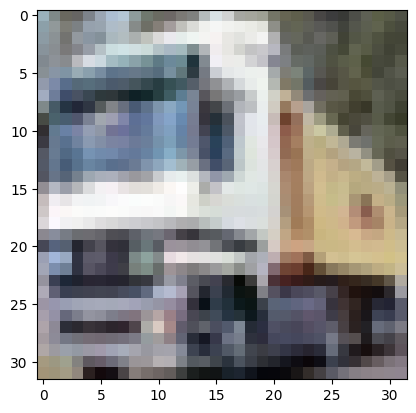

In [ ]:
# Download and load the CIFAR-10 training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',      # folder to store/load the data
    train=True,         # set True for training set
    download=True,      # download if not exists
    transform=transforms.ToTensor()
    #auto_transforms # apply transforms to data
)

test_dataset = torchvision.datasets.CIFAR10(
    root = './data',
    download = True,
    train = False,
    target_transform= False,
    transform=auto_transforms
)


len(train_dataset)
a, b = train_dataset[1]
plt.imshow(a.permute(1,2,0)) #auto_transforms a car

TypeError: ImageClassification.__init__() takes 1 positional argument but 2 positional arguments (and 3 keyword-only arguments) were given